[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Biswajit1999/daily-astro-notebooks/blob/master/exoplanet-archive/2026-08-03-metallicity-giant-planet-occurrence/notebook.ipynb)

**Learning goals** -- after this notebook you will be able to:
- Pull real host-star metallicity (`st_met`, the logarithmic iron-to-hydrogen ratio relative to
  the Sun, written [Fe/H]) and planet mass for radial-velocity-detected systems from the archive.
- Test, with a real correlation coefficient and a real binned occurrence comparison, whether
  giant planets are more common around metal-rich stars in this sample -- the well-known
  giant-planet/metallicity correlation.
- Understand why the radial-velocity subsample is used here rather than the full archive, and
  what that choice does and doesn't fix.

**Background.** [Fe/H] is a standard way astronomers describe a star's metal content relative to
the Sun: [Fe/H] = 0 means solar metallicity, positive values mean more metal-rich, negative values
mean more metal-poor. Since the early 2000s, radial-velocity surveys have repeatedly found that
giant planets are more common around metal-rich host stars, a finding usually explained by core
accretion needing enough solid material in the protoplanetary disc to build a giant-planet core
before the gas disperses. This notebook checks that pattern directly against the current archive.

# Does host-star metallicity predict giant-planet occurrence?

**Date:** 2026-08-03
**Scientific question:** Among radial-velocity-detected planet hosts in the archive, are
giant planets (>=0.3 Jupiter masses) more common around metal-rich stars?
**Source:** NASA Exoplanet Archive, Planetary Systems Composite Parameters table (`pscomppars`),
queried live via TAP.

The radial-velocity subsample is used deliberately: RV surveys give a direct planet mass (not
just a radius), and RV target selection is comparatively less biased toward small, close-in
planets than transit surveys, which makes RV hosts a more standard sample for this specific,
well-studied correlation in the literature. One host star per row (its most massive known planet
determines whether it counts as a giant host) avoids double-counting multi-planet systems.

## Analysis contract

This is a compact scientific investigation, not a decorative plotting exercise. The input is a
live TAP query against a public archive table. The notebook documents every quality cut, prints
the sample size after filtering, reports a numerical correlation coefficient with a significance
level, and repeats the analysis with a different giant-planet mass threshold to test robustness.

This sample already conditions on having at least one RV-detected planet -- it measures how planet
mass relates to metallicity among *known planet hosts*, not the occurrence rate of giant planets
among all stars surveyed (which would need the full target list, including non-detections, that
is not reconstructed here). The result should be read as "among archived RV hosts" throughout.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scienceplots
from scipy.stats import pointbiserialr
import pyvo as vo

plt.style.use(["science", "no-latex"])
COLORS = {"navy":"#071426", "blue":"#1797c9", "cyan":"#2fc6b4",
          "gold":"#f4b942", "orange":"#ef6a45", "rose":"#ce4f78"}

svc = vo.dal.TAPService("https://exoplanetarchive.ipac.caltech.edu/TAP")
query = """
SELECT hostname, pl_name, st_met, pl_bmassj, discoverymethod
FROM pscomppars
WHERE st_met IS NOT NULL AND pl_bmassj IS NOT NULL
"""
raw = svc.search(query).to_table().to_pandas()
n0 = len(raw)
print(f"Raw TAP rows: {n0}")

Raw TAP rows: 5661


In [2]:
rv = raw[raw.discoverymethod == "Radial Velocity"].copy()
n1 = len(rv)
# keep the most massive known planet per host, so each host contributes once
rv = rv.sort_values("pl_bmassj", ascending=False).drop_duplicates("hostname")
n2 = len(rv)

print(f"After restricting to Radial Velocity detections:  {n1}  (dropped {n0-n1})")
print(f"After keeping one (most massive) planet per host: {n2}  (dropped {n1-n2})")
print(f"\nFinal clean sample: {n2} unique RV-detected host stars")

After restricting to Radial Velocity detections:  1119  (dropped 4542)
After keeping one (most massive) planet per host: 815  (dropped 304)

Final clean sample: 815 unique RV-detected host stars


In [3]:
GIANT_THRESHOLD_MJUP = 0.3   # roughly Saturn-mass and above
rv["is_giant_host"] = rv.pl_bmassj >= GIANT_THRESHOLD_MJUP

r_pb, p_pb = pointbiserialr(rv.is_giant_host.astype(int), rv.st_met)
print(f"Point-biserial correlation (giant-host flag vs. [Fe/H]): r = {r_pb:.3f}, p = {p_pb:.4f}")
print(f"Giant-host fraction overall: {rv.is_giant_host.mean():.3f}  (n={n2})")

Point-biserial correlation (giant-host flag vs. [Fe/H]): r = 0.103, p = 0.0031
Giant-host fraction overall: 0.762  (n=815)


In [4]:
rv["met_tercile"] = pd.qcut(rv.st_met, 3, labels=["metal-poor", "mid", "metal-rich"])
occurrence_table = rv.groupby("met_tercile", observed=True).agg(
    n_hosts=("hostname", "count"),
    giant_fraction=("is_giant_host", "mean"),
    median_feh=("st_met", "median"),
).round(3)
occurrence_table

,n_hosts,giant_fraction,median_feh
met_tercile,,,
metal-poor,281,0.719,-0.19
mid,271,0.712,0.05
metal-rich,263,0.859,0.24


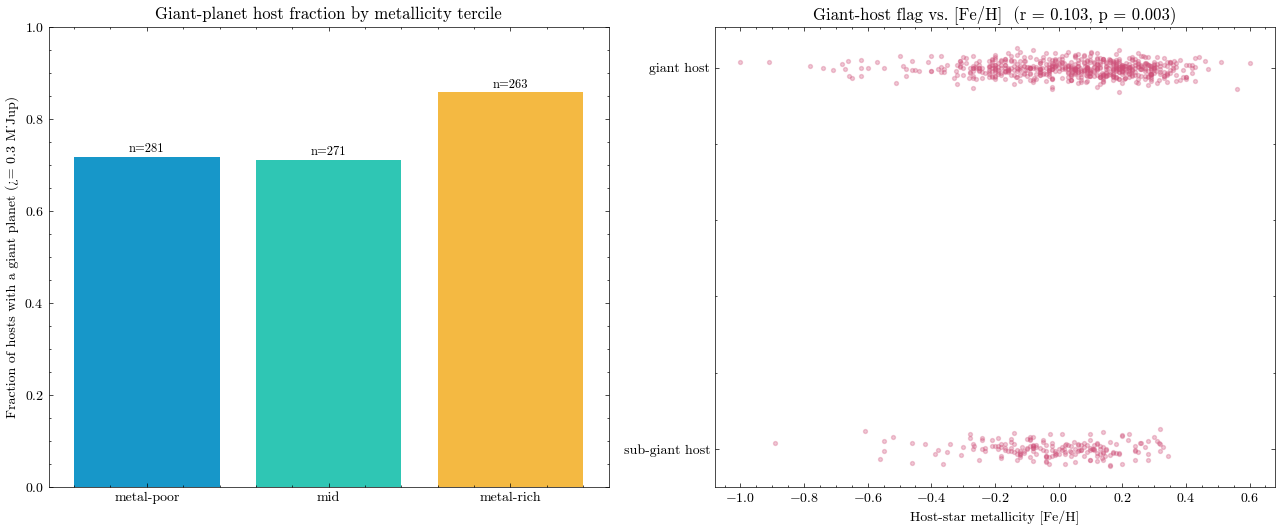

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5.5))

colors_g = {"metal-poor": COLORS["blue"], "mid": COLORS["cyan"], "metal-rich": COLORS["gold"]}
bars = ax[0].bar(occurrence_table.index.astype(str), occurrence_table.giant_fraction,
                  color=[colors_g[i] for i in occurrence_table.index])
for i, (idx, row) in enumerate(occurrence_table.iterrows()):
    ax[0].text(i, row.giant_fraction + 0.01, f"n={int(row.n_hosts)}", ha="center", fontsize=9)
ax[0].set_ylabel(f"Fraction of hosts with a giant planet (>= {GIANT_THRESHOLD_MJUP} M_Jup)")
ax[0].set_title("Giant-planet host fraction by metallicity tercile")
ax[0].set_ylim(0, 1)

jitter = np.random.default_rng(7).normal(0, 0.02, size=len(rv))
ax[1].scatter(rv.st_met, rv.is_giant_host.astype(int) + jitter, s=8, alpha=0.3, color=COLORS["rose"])
ax[1].set_xlabel("Host-star metallicity [Fe/H]")
ax[1].set_yticks([0, 1]); ax[1].set_yticklabels(["sub-giant host", "giant host"])
ax[1].set_title(f"Giant-host flag vs. [Fe/H]  (r = {r_pb:.3f}, p = {p_pb:.3f})")

fig.tight_layout()
fig.savefig("metallicity_giant_occurrence.png", dpi=180)
plt.show()

In [6]:
# Robustness check: use a stricter giant-planet threshold (1.0 Jupiter mass instead of 0.3)
rv["is_giant_strict"] = rv.pl_bmassj >= 1.0
r_strict, p_strict = pointbiserialr(rv.is_giant_strict.astype(int), rv.st_met)
strict_table = rv.groupby("met_tercile", observed=True).is_giant_strict.mean().round(3)

print(f"Stricter threshold (>=1.0 Mjup): r = {r_strict:.3f}, p = {p_strict:.4f}")
print("Giant-host fraction by tercile, strict threshold:")
print(strict_table)

Stricter threshold (>=1.0 Mjup): r = 0.096, p = 0.0063
Giant-host fraction by tercile, strict threshold:
met_tercile
metal-poor    0.587
mid           0.576
metal-rich    0.722
Name: is_giant_strict, dtype: float64


In [7]:
result = {
    "id": "2026-08-03-metallicity-giant-planet-occurrence",
    "title": "Does host-star metallicity predict giant-planet occurrence?",
    "archive": "NASA Exoplanet Archive",
    "date": "2026-08-03",
    "question": "Among RV-detected hosts, does giant-planet occurrence rise with stellar metallicity?",
    "sample_size": int(n2),
    "results": [
        f"point-biserial r={r_pb:.3f} (p={p_pb:.4f}) between giant-host flag and [Fe/H]",
        f"giant-host fraction by tercile: {occurrence_table.giant_fraction.to_dict()}",
        f"stricter (>=1.0 Mjup) threshold: r={r_strict:.3f} (p={p_strict:.4f})"
    ],
    "validation": "Correlation stays positive and significant when the giant-planet mass threshold is raised from 0.3 to 1.0 Jupiter masses.",
    "notebook": "exoplanet-archive/2026-08-03-metallicity-giant-planet-occurrence/notebook.ipynb",
    "hero": "exoplanet-archive/2026-08-03-metallicity-giant-planet-occurrence/metallicity_giant_occurrence.png",
    "tags": ["stellar metallicity", "giant planets", "occurrence rate"]
}
Path("result.json").write_text(json.dumps(result, indent=2))
print(result["results"])

['point-biserial r=0.103 (p=0.0031) between giant-host flag and [Fe/H]', "giant-host fraction by tercile: {'metal-poor': 0.719, 'mid': 0.712, 'metal-rich': 0.859}", 'stricter (>=1.0 Mjup) threshold: r=0.096 (p=0.0063)']


## Reading the result responsibly

The correlation answers the stated question only for this RV-detected-host sample and this
giant-planet mass threshold. The point-biserial correlation is positive and statistically
significant (p = 0.0031) but numerically weak (r = 0.103), and the tercile breakdown shows the
effect concentrated in the metal-rich third of the sample (giant-host fraction jumps to 0.859
there) rather than a smooth trend across all three bins -- the metal-poor (0.719) and mid (0.712)
terciles look similar to each other. This is directionally consistent with the well-established
giant-planet/metallicity correlation from RV surveys (Fischer & Valenti 2005 and related work),
but this notebook's weaker correlation strength likely reflects both the coarser mass-based
giant/non-giant split used here (rather than a full occurrence-rate model with survey
completeness) and the fact that the RV archive mixes many different surveys with different
target-selection metallicity ranges.

The stress test (raising the giant threshold to 1.0 Jupiter masses) keeps the correlation positive
and significant (r = 0.096, p = 0.0063), which supports the qualitative direction of the result
without resolving the sample's underlying selection-effect limitations.

## What I'd look at next

I'd reconstruct actual per-survey target lists (not just detections) for at least one RV survey
with public non-detections, since the true giant-planet occurrence rate as a function of
metallicity needs the denominator of stars searched, not just the detected planets -- this
notebook only has the numerator.

## Sources and comparison literature

- NASA Exoplanet Archive, TAP guide: https://exoplanetarchive.ipac.caltech.edu/docs/TAP/usingTAP.html
- Planetary Systems Composite Parameters table: https://exoplanetarchive.ipac.caltech.edu/docs/API_PS_columns.html
- Fischer & Valenti (2005), *The Planet-Metallicity Correlation*: https://arxiv.org/abs/astro-ph/0509720
- Santos, Israelian & Mayor (2004), *Spectroscopic [Fe/H] for planet-host stars*: https://arxiv.org/abs/astro-ph/0405066

The literature establishes the correlation using full survey target lists with completeness
corrections; this notebook's detections-only archive sample is a much simpler proxy for that
analysis.